****Question 1****: What is the role of filters and feature maps in Convolutional Neural
Network (CNN)?

### The Role of Filters and Feature Maps in a CNN

In a Convolutional Neural Network (CNN), **filters** (also known as kernels) and **feature maps** are fundamental components for image analysis. They work together to extract meaningful patterns from input data.

#### Filters
A filter is a small matrix of numbers that slides over the input image, performing a mathematical operation called a **convolution**. Each filter is designed to detect a specific type of feature in the image, such as:
* Edges (horizontal, vertical, or diagonal)
* Textures
* Corners or curves

During the convolution operation, the filter multiplies its values by the corresponding pixel values in the input image. It then sums up the products to produce a single value. This process is repeated as the filter moves across the entire image. The weights (numbers) within a filter are learned during the training process to best detect the desired features.

***

#### Feature Maps
A **feature map** (or activation map) is the output of the convolution operation. It is a new, smaller matrix that records the presence and location of the features detected by a specific filter.
* A **high value** in the feature map indicates that the filter's feature was strongly detected at that location in the original image.
* A **low value** means the feature was not strongly present.

Each filter applied to the input image will create its own unique feature map. For example, a filter designed to detect horizontal edges will produce a feature map where high values correspond to horizontal edges in the original image. These feature maps then serve as the input for the next layer in the network, allowing the CNN to learn increasingly complex and abstract features in deeper layers.

In essence, filters are the "feature detectors," and feature maps are the "maps" that show where those features were found.

***-----------------------------------------------------------------------------------------------------------------------------***


***Question 2***: Explain the concepts of padding and stride in CNNs(Convolutional Neural
Network). How do they affect the output dimensions of feature maps?

Padding and stride are key hyperparameters that control the size of the output feature map and how information is processed within a CNN.

-----

### Padding

Padding is the process of adding extra rows and columns of pixels (usually filled with zeros) to the border of the input image before a convolution operation.

#### Role:

  * **Preserving Edge Information:** Without padding, the pixels at the edges of the image are used fewer times in the convolution than the pixels in the center. This can lead to the loss of valuable information. Padding ensures that the filter can fully operate on the border pixels, preventing this data loss.
  * **Maintaining Spatial Dimensions:** As a filter slides over an image without padding, the output feature map naturally becomes smaller. Padding is used to counteract this reduction, allowing the output to maintain the same dimensions as the input. This is particularly useful for building very deep networks where the feature maps shouldn't shrink too quickly.

#### Effect on Output Dimensions:

Padding **increases** the output dimensions of the feature map relative to a non-padded convolution. The most common types are "Valid" padding (no padding, shrinking output) and "Same" padding (adds padding to make the output size the same as the input size).

-----

### Stride

Stride refers to the number of pixels the filter moves at each step during the convolution.

#### Role:

  * **Downsampling:** A stride greater than 1 makes the filter "jump" across the image, skipping some pixels. This effectively downsamples the feature map, reducing its size and the number of computations required. This is an efficient way to decrease the spatial dimensions of the data.
  * **Controlling Computational Cost:** Larger strides lead to a smaller output, which reduces the computational load and speeds up training and inference.

#### Effect on Output Dimensions:

Stride **decreases** the output dimensions of the feature map. A larger stride results in a more significant reduction in size.

-----

### How They Affect Output Dimensions:

The relationship between input size, padding, and stride is defined by the following formula for a single dimension (like width or height):

$$\text{Output Dimension} = \lfloor \frac{W - F + 2P}{S} \rfloor + 1$$

Where:

  * **W** is the input dimension (e.g., width or height).
  * **F** is the filter size.
  * **P** is the amount of padding.
  * **S** is the stride.
  * The $\\lfloor \\rfloor$ symbol denotes the floor function, which rounds the result down to the nearest integer.



***------------------------------------------------------------------------------------------------------------------------------***


***Question 3:*** Define receptive field in the context of CNNs. Why is it important for deep
architectures?

### Receptive Field in CNNs

The **receptive field** of a neuron in a CNN is the region in the input image that influences the output of that neuron. In simpler terms, it's the specific area of the original image that a neuron "sees" to make its decision or produce a feature. Unlike a traditional neural network where every neuron is connected to every input, a CNN neuron is only connected to a local patch of the previous layer's output (its receptive field).

The size of the receptive field is not fixed. It grows as you go deeper into the network. For a neuron in a given layer, its receptive field is determined by the size of the filters and the strides in all the preceding layers. A small filter in an early layer might only "see" a 3x3 pixel area, but as the network stacks more convolutional and pooling layers, the receptive field of a neuron in a deeper layer expands, allowing it to take in information from a much larger area of the original image.

***

### Importance for Deep Architectures

The concept of a growing receptive field is crucial for deep CNN architectures because it enables the network to learn a **hierarchical representation** of the image.

1.  **Hierarchical Feature Extraction:**
    * **Early layers** have small receptive fields and learn to detect low-level features like edges, corners, and textures.
    * **Intermediate layers** have larger receptive fields and can combine these simple features to recognize more complex patterns, such as a wheel, an eye, or a window.
    * **Deeper layers** have very large receptive fields, allowing them to detect entire objects, like a car or a face, by integrating the complex patterns from the previous layers.

2.  **Contextual Understanding:** For tasks like semantic segmentation or object detection, the network needs to understand the context of an object. A large receptive field allows a neuron to gather information from a wide surrounding area, helping it to distinguish between a tire on a car and a loose tire in a garage, for example. Without a sufficiently large receptive field, the model might only identify parts of an object or struggle to classify large objects.

3.  **Efficiency and Parameter Sharing:** The receptive field concept is what makes CNNs so efficient. By only connecting to local regions and sharing weights across the entire image (the filter), the network drastically reduces the number of parameters it needs to learn, making it feasible to train very deep architectures on large image datasets.


***------------------------------------------------------------------------------------------------------------------------------***


**Question** : **4**
 : Discuss how filter size and stride influence the number of parameters in a
CNN

In a CNN's convolutional layer, **filter size** directly influences the number of parameters, while **stride** does not.

### Filter Size and Parameters
The number of parameters in a convolutional layer is determined by the dimensions of its filters and the number of filters. The formula is:

$$\text{Parameters} = (\text{filter height} \times \text{filter width} \times \text{input channels} + 1) \times \text{number of filters}$$

* **Filter Size (height x width):** Increasing the filter size (e.g., from 3x3 to 5x5) directly increases the number of weights per filter, leading to a significant increase in the total number of parameters. A larger filter sees a larger area of the input, but this comes at the cost of a more complex model.

### Stride and Parameters
Stride is the number of pixels the filter moves at each step.

* **Stride does not change the number of parameters.** The parameters of a convolutional layer (the filter weights and biases) are fixed once the filter is defined. The stride only affects **how often** that filter is applied across the input and, consequently, the **output dimensions** of the feature map. It does not alter the values within the filter itself.

In summary, filter size is a key factor in determining a CNN's parameter count, directly affecting model complexity and memory usage. Stride, on the other hand, is a computational and downsampling control that influences the output size and efficiency without changing the number of learned parameters.

***------------------------------------------------------------------------------------------------------------------------------***


**Question** 5: Compare and contrast different CNN-based architectures like LeNet,
AlexNet, and VGG in terms of depth, filter sizes, and performance.


Here is a comparison and contrast of three foundational CNN architectures: LeNet, AlexNet, and VGG.

### LeNet
* **Depth:** A shallow network with only **7 layers** (5 convolutional/pooling layers and 2 fully-connected layers).
* **Filter Sizes:** Used relatively large filter sizes, primarily **5x5**.
* **Performance:** A pioneering architecture that successfully performed digit recognition on small, grayscale images (32x32 pixels). Its performance was groundbreaking for its time but is far surpassed by modern networks on complex datasets.
* **Key Contribution:** Demonstrated the power of CNNs for image recognition, establishing the core building blocks of convolution, pooling, and fully connected layers.

---

### AlexNet
* **Depth:** Deeper than LeNet with **8 layers** (5 convolutional and 3 fully-connected).
* **Filter Sizes:** Started with a very large **11x11 filter** in the first layer, followed by smaller filters (5x5, 3x3) in deeper layers.
* **Performance:** Won the 2012 ImageNet competition with a significantly lower error rate than previous models. This achievement is widely considered the catalyst for the modern deep learning revolution.
* **Key Contributions:** Proved that **deeper networks** could achieve superior performance on large, complex datasets. It introduced key innovations like **ReLU activation** to speed up training and **dropout** to prevent overfitting. It also demonstrated the power of using GPUs for training large models.

---

### VGG
* **Depth:** Much deeper than both LeNet and AlexNet, with variants like VGG-16 and VGG-19 having **16 and 19 layers**, respectively.
* **Filter Sizes:** A key architectural principle of VGG is its **uniformity**. It exclusively uses small **3x3 filters** throughout the entire network. The creators found that stacking multiple small filters (e.g., three 3x3 filters) is computationally more efficient and provides more non-linearity than using one large filter (e.g., a single 7x7 filter), while having the same receptive field.
* **Performance:** Achieved top performance in the 2014 ImageNet competition. Its accuracy was a testament to the power of depth in a straightforward, uniform design. However, its performance came at a cost: it has a very high number of parameters (over 138 million), making it computationally expensive and slow to train.
* **Key Contribution:** Showed that increasing network depth with a very simple, repetitive architecture could lead to state-of-the-art results. It popularized the use of **small, uniform filters** as a standard design choice in CNNs.

***------------------------------------------------------------------------------------------------------------------------------***


**Question** 6 : Using keras, build and train a simple CNN model on the MNIST dataset
from scratch. Include code for module creation, compilation, training, and evaluation.


In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
(x_train,y_train),(x_test,y_test) = datasets.mnist.load_data()
x_train =x_train.astype("float32")/255.0
x_test= x_test.astype("float32")/255.0

x_train = tf.expand_dims(x_train, axis=-1)
x_test = tf.expand_dims(x_test, axis=-1)

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

#bulild model
model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax'),
])

model.compile(optimizer='adam',loss="sparse_categorical_crossentropy",metrics =["accuracy"])
model.summary()

#train model
history =model.fit(x_train,y_train,epochs=5,batch_size=64,validation_data=(x_test,y_test))
test_loss,test_accur =model.evaluate(x_test,y_test,verbose=2)
print("\nTest accuracy:", test_accur)

plt.plot(history.history['accuracy'],label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


**Question 7:** Load and preprocess the CIFAR-10 dataset using Keras, and create a
CNN model to classify RGB images. Show your preprocessing and architecture.

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10,
                    batch_size=64,
                    validation_data=(x_test, y_test))

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print("\nTest Accuracy:", test_acc)

# Plot training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


**Question 8**: Using PyTorch, write a script to define and train a CNN on the MNIST
dataset. Include model definition, data loaders, training loop, and accuracy evaluation.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.fc1 = nn.Linear(64*5*5, 128)
        self.fc2 = nn.Linear(128, 10)
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64*5*5)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Epoch {epoch+1}, Test Accuracy: {100 * correct / total:.2f}%")


**Question 9:** Given a custom image dataset stored in a local directory, write code using
Keras ImageDataGenerator to preprocess and train a CNN model.


In [ ]:
import gdown

# Google Drive file ID
file_id = "1TCU1nqgIe1R_dW6LTkRxlufHlCCazyJl"
# Download destination filename
output = "myfile.zip"

# Download the file
gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)

import zipfile

with zipfile.ZipFile("myfile.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

Downloading...
From (original): https://drive.google.com/uc?id=1TCU1nqgIe1R_dW6LTkRxlufHlCCazyJl
From (redirected): https://drive.google.com/uc?id=1TCU1nqgIe1R_dW6LTkRxlufHlCCazyJl&confirm=t&uuid=27486d82-a2e2-4099-af6a-d3213b7c4aaf
To: /content/myfile.zip
100%|██████████| 63.9M/63.9M [00:01<00:00, 61.6MB/s]


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


train_dir = "/content/dataset/train"
test_dir ="/content/dataset/test"
val_dir   = "/content/dataset/valid"

# Image augmentation for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,         # normalize pixels
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Only rescaling for test data
test_datagen = ImageDataGenerator(rescale=1./255)

# Load images from local directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode="binary"      # binary classification
)

test_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode="binary"
)
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # sigmoid for binary classification
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10
)

# Only rescaling for test data
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode="binary",
    shuffle=False  # important to keep order for evaluation
)
# Evaluate loss and accuracy on test set
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")





Found 1275 images belonging to 2 classes.
Found 364 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 325ms/step - accuracy: 0.5214 - loss: 0.7203 - val_accuracy: 0.5824 - val_loss: 0.6281
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 197ms/step - accuracy: 0.7023 - loss: 0.5946 - val_accuracy: 0.8049 - val_loss: 0.4890
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 182ms/step - accuracy: 0.7591 - loss: 0.5091 - val_accuracy: 0.8022 - val_loss: 0.4493
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 190ms/step - accuracy: 0.7738 - loss: 0.4863 - val_accuracy: 0.7940 - val_loss: 0.4111
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 197ms/step - accuracy: 0.7985 - loss: 0.4220 - val_accuracy: 0.8352 - val_loss: 0.3709
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 173ms/step - accuracy: 0.8163 - loss: 0.4346 - val_accuracy: 0.8104 - val_loss: 0.3866
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 196ms/step - accuracy: 0.8478 - loss: 0.3699 - val_accuracy: 0.8269 - val_loss: 0.4004
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 192ms/step - accuracy: 0.8249 - loss: 0.4074 - val_accuracy: 0

***Question*** **10**: You are working on a web application for a medical imaging startup. Your
task is to build and deploy a CNN model that classifies chest X-ray images into “Normal”
and **“Pneumonia”** categories. Describe your end-to-end approach–from data preparation
and model training to deploying the model as a web app using Streamlit.

In [ ]:
import streamlit as st
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import cv2

# Load the trained model
@st.cache_resource
def load_model():
    model = tf.keras.models.load_model('pneumonia_classifier_model.h5')
    # model = tf.keras.models.load_model('pneumonia_classifier_model')
    return model

model = load_model()

# Define classes and image size
class_names = ['Normal', 'Pneumonia']
img_height, img_width = 150, 150

# Streamlit UI
st.title('Chest X-Ray Pneumonia Classifier')
st.markdown('Upload a chest X-ray image to get a prediction.')

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    # Display the uploaded image
    st.image(uploaded_file, caption='Uploaded Image.', use_column_width=True)
    st.write("")

    # Make prediction on button click
    if st.button('Predict'):
        # Preprocess the image for the model
        img_array = image.img_to_array(image.load_img(uploaded_file, target_size=(img_height, img_width)))
        img_array = np.expand_dims(img_array, axis=0) # Create a batch
        img_array = img_array / 255.0 # Normalize

        # Make prediction
        prediction = model.predict(img_array)[0][0]
        st.write("---")

        # Display the result
        if prediction < 0.5:
            st.success(f"**Prediction:** Normal")
            st.info(f"Confidence: {100 - prediction * 100:.2f}%")
        else:
            st.error(f"**Prediction:** Pneumonia")
            st.info(f"Confidence: {prediction * 100:.2f}%")

The Live demo of the website : https://xray-prediction-pneumonia-or-normal.streamlit.app/

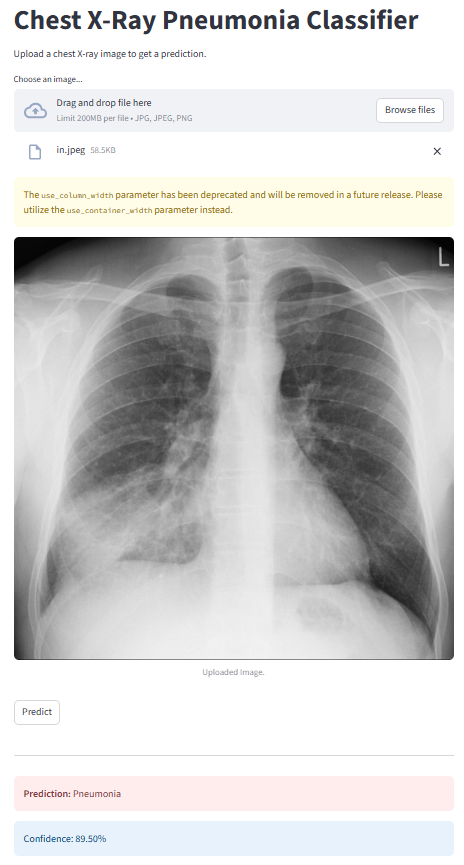